In [14]:
import matplotlib.pyplot as plt

In [118]:
def bisection_method(func, x0: float, x1: float, residual: float = 1e-4, max_iterations: int = 100):
    if func(x0) * func(x1) >= 0:
        raise ValueError("f(x0) and f(x1) must have opposite signs")

    iterations = 0
    history = []

    while iterations < max_iterations:
        c = (x0 + x1) / 2
        ay = func(x0)
        cy = func(c)

        history.append({
            "iteration": iterations,
            "a": x0,
            "b": x1,
            "c": c,
            "f(x)": cy
        })

        if abs(cy) < residual or abs(x1 - x0) < residual:
            return iterations, c, cy, history

        if ay * cy < 0:
            x1 = c
        else:
            x0 = c

        iterations += 1

    return iterations, c, cy, history

def bisection_method_plot(func, x0: float, x1: float, residual: float = 1e-4, max_iterations: int = 100):
    iterations, root, value, history = bisection_method(func, x0, x1, residual, max_iterations)
    print("iterations:", str(iterations))
    print("root:", str(root))
    print("residual:", str(value))
    
    iterations = [h["iteration"] for h in history]
    values = [h["f(x)"] for h in history]
    
    plt.plot(iterations, values, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel("f(x)")
    plt.title("Bisection Convergence")
    plt.show()

iterations: 13
root: 1.41424560546875
residual: 9.063258767127991e-05


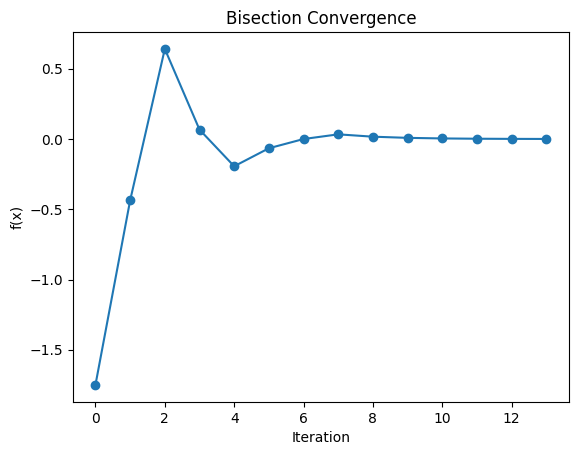

In [119]:
bisection_method_plot(lambda x: x*x - 2, -1, 2)

In [159]:
def newton_raphson_method(func, dfunc, x0, residual=1e-6, max_iter=10):
    x = x0
    history = []

    for i in range(max_iter):
        fx = func(x)
        dfx = dfunc(x)
        
        if abs(dfx) < 1e-12:
            break

        x_new = x - fx/dfx

        history.append({
            "iteration": i,
            "x": x,
            "y": x_new,
        })
        
        if abs(func(x_new)) < residual:
            return x_new, history

        x = x_new

    return x_new, history

def newton_raphson_method_plot(func, dfunc, x0, residual=1e-6, max_iter=10):
    root, history = newton_raphson_method(func, dfunc, x0, residual, max_iter)

    print("root:", root)

    iterations = [0] + [h["iteration"] + 1 for h in history]
    values = [x0] + [h["y"] for h in history]

    plt.plot(iterations, values, marker="o")

    plt.scatter(0, x0)

    plt.xlabel("Iteration")
    plt.ylabel("x value")
    plt.title("Newton-Raphson Convergence")

    plt.show()

root: (1023.9999999999968-2.579658093032714e-12j)


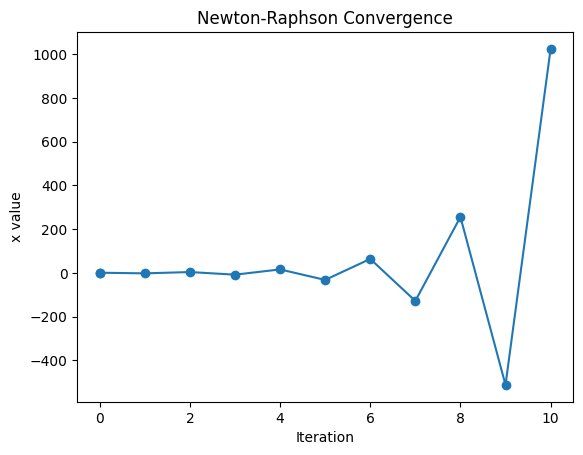

In [163]:
newton_raphson_method_plot(
    lambda x: x**(1/3),
    lambda x: 1/(3*(x**(2/3))),
    1
)